In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.signal import find_peaks
import random
from scipy.signal import savgol_filter
import scipy.stats

In [2]:
CONTEXT = 100

class Pipeline:

    d = None
    d_left = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):

        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)

        if len(self.x) < 50:
            return
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max(self.x)
        self.y = self.__normalization_min_max(self.y)
        self.x_left = self.__normalization_min_max(self.x_left)
        self.y_left = self.__normalization_min_max(self.y_left)

        self.d = self.__calculate_distance(self.x, self.y)
        self.d_left = self.__calculate_distance(self.x_left, self.y_left)
        
        self.__calculate_diff()
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)
        
        self.x_diff = self.__highpass_filtering(self.x_diff)
        self.y_diff = self.__highpass_filtering(self.y_diff)
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__smooth_signal(self.x_diff)
        self.y_diff = self.__smooth_signal(self.y_diff)

        self.x_diff = self.__highligth_peaks(self.x_diff)
        self.y_diff = self.__highligth_peaks(self.y_diff)

        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__lowpass_filtering(self.x_diff)
        self.y_diff = self.__lowpass_filtering(self.y_diff)
        
        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__zero_outliers(self.x_diff)
        self.y_diff = self.__zero_outliers(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_mask = self.__detect_peaks(self.x_diff, prominence=0.05, distance=10)
        self.y_mask = self.__detect_peaks(self.y_diff, prominence=0.05, distance=10)

        # self.__plot_results()

        self.d = self.__normalization_min_max_positive(self.d)
        self.d_left = self.__normalization_min_max_positive(self.d_left)
        
        self.mask = self.__contextual_dot_product(self.x_mask, self.y_mask, context=10)
        
        results_features = self.__analyze_binary_signal(self.mask)

        self.x = self.__normalization_min_max_positive(self.x)
        self.y = self.__normalization_min_max_positive(self.y)
        self.x_left = self.__normalization_min_max_positive(self.x_left)
        self.y_left = self.__normalization_min_max_positive(self.y_left)
        
        x_saccade = self.__extract_peak_segments(self.x, self.mask, context_size=CONTEXT)
        y_saccade = self.__extract_peak_segments(self.y, self.mask, context_size=CONTEXT)
        x_left_saccade = self.__extract_peak_segments(self.x_left, self.mask, context_size=CONTEXT)
        y_left_saccade = self.__extract_peak_segments(self.y_left, self.mask, context_size=CONTEXT)
        d_saccade = self.__extract_peak_segments(self.d, self.mask, context_size=CONTEXT)
        d_left_saccade = self.__extract_peak_segments(self.d_left, self.mask, context_size=CONTEXT)

        results_fragments = (y_saccade,y_saccade,y_saccade,y_saccade,y_saccade,y_saccade,)
        
        return results_features, results_fragments

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __calculate_distance(self, x, y):
        return np.sqrt(np.power(x, 2) + np.power(y, 2))
        
    def __calculate_diff(self):
        self.x_diff = abs(self.x - self.x_left)
        self.y_diff = abs(self.y - self.y_left)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())

    def __normalization_min_max(self, signal):
        return 2*((signal - signal.min()) / (signal.max() - signal.min())) - 1

    def __strech_signal(self, signal):
        power = 2
        mean = signal.mean()
        
        signal = np.power(signal, power)
        signal = signal / signal.mean() * mean

        return signal

    def __highpass_filtering(self, signal):
        def highpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Change to 'high'
            return filtfilt(b, a, data)

        return highpass_filter(signal)

    def __smooth_signal(self, signal, sigma=5):
        return gaussian_filter1d(signal, sigma=sigma)

    def __highligth_peaks(self,signal):
        difference_kernel = np.array([-1,-1, 0, 1,1]) 
        return convolve(signal, difference_kernel, mode="same")

    def __lowpass_filtering(self, signal):
        def lowpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return filtfilt(b, a, data)

        return lowpass_filter(signal)

    def __zero_outliers(self, signal):
        Q1 = np.percentile(signal, 5) 
        Q3 = np.percentile(signal, 95)
        IQR = Q3 - Q1
        
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        filtered_signal = signal.copy()
        filtered_signal[(filtered_signal < lower) | (filtered_signal > upper)] = 0
    
        return filtered_signal

    def __detect_peaks(self, signal, height=None, prominence=0.1, distance=5):
        signal = np.array(signal)
        peaks, _ = find_peaks(signal, height=height, prominence=prominence, distance=distance)
        peak_mask = np.zeros(len(signal), dtype=int)
        peak_mask[peaks] = 1
        
        return peak_mask

    def __plot_results(self):

        start = 32498
        end = start + 200
        
        fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
        
        axes[0].plot(self.t.iloc[start:end], self.x.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[0].set_ylabel("X Position Rigth Eye")
        axes[0].set_title("X vs Time")
        axes[0].grid(True)
        
        axes[1].plot(self.t.iloc[start:end], self.x_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[1].set_xlabel("Time (Normalized)")
        axes[1].set_ylabel("X Position Left Eye")
        axes[1].set_title("X vs Time")
        axes[1].grid(True)
        
        axes[2].plot(self.t.iloc[start:end], self.x_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[2].set_xlabel("Time (Normalized)")
        axes[2].set_ylabel("X Diffrence")
        axes[2].set_title("saccade movement")
        axes[2].grid(True)

        axes[3].plot(self.t.iloc[start:end], self.y.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[3].set_ylabel("X Position Rigth Eye")
        axes[3].set_title("Y vs Time")
        axes[3].grid(True)
        
        axes[4].plot(self.t.iloc[start:end], self.y_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[4].set_xlabel("Time (Normalized)")
        axes[4].set_ylabel("X Position Left Eye")
        axes[4].set_title("Y vs Time")
        axes[4].grid(True)
        
        axes[5].plot(self.t.iloc[start:end], self.y_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[5].set_xlabel("Time (Normalized)")
        axes[5].set_ylabel("X Diffrence")
        axes[5].set_title("saccade movement")
        axes[5].grid(True)
        
        plt.tight_layout()
        plt.show()

    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments

    def __generate_smoothed_signal(self, fragments):
        if not fragments:
            return
        random.shuffle(fragments)
        smoothed_signal = [fragments[0]]
    
        last_value = fragments[0][-1]
    
        for i in range(1, len(fragments)):
            shift = last_value - fragments[i][0]
            translated_fragment = fragments[i] + shift
    
            smoothed_signal.append(translated_fragment)
            last_value = translated_fragment[-1]

        yield np.concatenate(smoothed_signal)

    def __savgol_filter(self, signal):
        return savgol_filter(signal, window_length=11, polyorder=3)
    
    def __idt(self, x, y, t, velocity_threshold=30):
        dx = np.diff(x)
        dy = np.diff(y)
        dt = np.diff(t)
    
        velocity = np.sqrt(dx**2 + dy**2) / dt  
        velocity = np.insert(velocity, 0, 0)
    
        saccade_mask = velocity > velocity_threshold
        saccade_mask = saccade_mask.astype(int)
    
        return saccade_mask
    
    def __contextual_dot_product(self, signal1, signal2, context):
        assert len(signal1) == len(signal2), "Signals must be of equal length"
    
        # Create a kernel with ones in the given context range
        kernel = np.ones(2 * context + 1)
    
        # Convolve signal2 with the kernel (this spreads 1s over the context)
        spread_signal2 = convolve(signal2, kernel, mode='same')  # 'same' keeps original size
    
        # Convert convolved signal to binary (any nonzero value means a 1 was nearby)
        spread_signal2 = (spread_signal2 > 0).astype(int)
    
        # Perform element-wise AND (dot product-like)
        result = signal1 * spread_signal2
        return result

    def __analyze_binary_signal(self, signal: np.ndarray):
        """Compute various characteristics of a binary signal containing 0s and 1s."""
        if len(signal) == 0:
            return {"Error": "Empty signal provided"}
    
        # 1. Total Length of Signal
        total_length = len(signal)
    
        # 2. Count of 1s and 0s
        count_ones = np.sum(signal)
        count_zeros = total_length - count_ones
    
        # 3. Proportion of 1s (Density of 1s)
        density_ones = count_ones / total_length
    
        # 4. First and Last Occurrence of 1
        first_one = np.where(signal == 1)[0][0] if count_ones > 0 else None
        last_one = np.where(signal == 1)[0][-1] if count_ones > 0 else None
    
        # 5. Run-Lengths (Consecutive 1s and 0s)
        changes = np.diff(np.concatenate(([0], signal, [0])))
        run_lengths = np.where(changes != 0)[0]
        run_lengths = np.diff(run_lengths) if len(run_lengths) > 1 else np.array([])
        ones_run_lengths = run_lengths[::2] if len(run_lengths) > 0 else np.array([])
        zeros_run_lengths = run_lengths[1::2] if len(run_lengths) > 1 else np.array([])
        
        avg_ones_run_length = np.mean(ones_run_lengths) if ones_run_lengths.size > 0 else 0
        avg_zeros_run_length = np.mean(zeros_run_lengths) if zeros_run_lengths.size > 0 else 0
    
        # 6. Interarrival Time of 1s (Gaps Between 1s)
        ones_positions = np.where(signal == 1)[0]
        interarrival_times = np.diff(ones_positions) if len(ones_positions) > 1 else np.array([])
        avg_interarrival_time = np.mean(interarrival_times) if interarrival_times.size > 0 else None
        std_interarrival_time = np.std(interarrival_times) if interarrival_times.size > 0 else None
    
        # 7. Shannon Entropy
        p1 = count_ones / total_length
        p0 = count_zeros / total_length
        entropy = -p1 * np.log2(p1) - p0 * np.log2(p0) if p1 > 0 and p0 > 0 else 0
    
        # 8. Markov Transition Probabilities
        transitions = np.column_stack((signal[:-1], signal[1:]))
        total_transitions = len(transitions)
        if total_transitions > 0:
            p_11 = np.sum((transitions[:, 0] == 1) & (transitions[:, 1] == 1)) / count_ones if count_ones > 0 else 0
            p_10 = np.sum((transitions[:, 0] == 1) & (transitions[:, 1] == 0)) / count_ones if count_ones > 0 else 0
            p_01 = np.sum((transitions[:, 0] == 0) & (transitions[:, 1] == 1)) / count_zeros if count_zeros > 0 else 0
            p_00 = np.sum((transitions[:, 0] == 0) & (transitions[:, 1] == 0)) / count_zeros if count_zeros > 0 else 0
        else:
            p_11 = p_10 = p_01 = p_00 = None
    
        # 9. Longest Streak of 1s
        max_ones_streak = np.max(ones_run_lengths) if ones_run_lengths.size > 0 else 0
    
        # 10. Longest Streak of 0s
        max_zeros_streak = np.max(zeros_run_lengths) if zeros_run_lengths.size > 0 else 0
    
        # 11. Standard Deviation of Run-Lengths for 1s
        std_ones_run_length = np.std(ones_run_lengths) if ones_run_lengths.size > 0 else 0
    
        # 12. Standard Deviation of Run-Lengths for 0s
        std_zeros_run_length = np.std(zeros_run_lengths) if zeros_run_lengths.size > 0 else 0
    
        # 13. Skewness of Interarrival Times
        skewness_interarrival = scipy.stats.skew(interarrival_times) if interarrival_times.size > 0 else None
    
        # 14. Kurtosis of Interarrival Times
        kurtosis_interarrival = scipy.stats.kurtosis(interarrival_times) if interarrival_times.size > 0 else None
    
        # 15. Compression Ratio (Approximation)
        compression_ratio = len(set(signal.tobytes())) / total_length if total_length > 0 else None
    
        return (
            # total_length,
            count_ones,
            count_zeros,
            density_ones,
            first_one,
            last_one,
            avg_ones_run_length,
            avg_zeros_run_length,
            avg_interarrival_time,
            std_interarrival_time,
            entropy,
            p_11,
            p_10,
            p_01,
            p_00,
            max_ones_streak,
            max_zeros_streak,
            std_ones_run_length,
            std_zeros_run_length,
            skewness_interarrival,
            kurtosis_interarrival,
            compression_ratio
        )




In [3]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = Pipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

input_size = len(saccade_signals[0])
num_features = len(saccade_signals[1])

# fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

# for signal in saccade_signals[3][:10]:
    # axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
# axes.set_ylabel("Rigth Eye")
# axes.set_title("Distance vs Time")
# axes.grid(True)

# print(len(saccade_seq))

In [4]:
labels = [0,1,8] # [0,1] -> 100% accuracy
labels_num = len(labels)

In [5]:
num_signals = 10
sequence_length = 2 * CONTEXT + 1

In [6]:
import pandas as pd

# Selected columns to read from each CSV file
selected_columns = [
    "t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"
]

# Renaming dictionary (base names)
rename_dict = {
    "t": "t", 
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
}

# List to store all DataFrames
df_list = []

# Load each CSV file and process it
for i in labels:  # Loop from 00 to 09
    file_path = f"../data/{i:02d}/data.csv"  # Format path dynamically
    
    # Load CSV, only select needed columns
    df = pd.read_csv(file_path, usecols=selected_columns)
    
    # Trim to 100,000 rows
    df = df.iloc[:100000]
    
    # Rename columns with appropriate suffix
    df = df.rename(columns={col: f"{rename_dict[col]}{i:02d}" for col in selected_columns})
    
    # Append processed DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames side-by-side
merged_df = pd.concat(df_list, axis=1)

merged_df.head()


,t00,x00,y00,x_left00,y_left00,t01,x01,y01,x_left01,y_left01,t08,x08,y08,x_left08,y_left08
0,1.581362e+15,-29.585846,1.740021,32.436142,5.695251,1.583335e+15,-33.649307,0.915329,29.914169,4.788696,1.583765e+15,-33.262161,5.119858,29.977646,6.512436
1,1.581362e+15,-29.591797,1.740555,32.421951,5.614624,1.583335e+15,-33.651520,0.925964,29.914185,4.745239,1.583765e+15,-33.262024,5.121719,29.980591,6.509903
2,1.581362e+15,-29.599228,1.711990,32.406448,5.580765,1.583335e+15,-33.654449,0.910370,29.913483,4.757553,1.583765e+15,-33.256668,5.013565,29.983536,6.507385
3,1.581362e+15,-29.606445,1.710693,32.386810,5.647583,1.583335e+15,-33.655487,0.906570,29.913757,4.726425,1.583765e+15,-33.253677,5.046753,29.986649,6.505325
4,1.581362e+15,-29.615341,1.769791,32.370270,5.730347,1.583335e+15,-33.656067,0.902786,29.921448,4.677521,1.583765e+15,-33.253036,5.035599,29.989761,6.507141


In [7]:
import pandas as pd
import numpy as np

# List of signal types to extract
signal_types = ["t", "x", "y", "x_left", "y_left"]

# Create an empty list to store instances
instances = []

total_length = int(1e5)
segment_num = int(1e1)
segment_length = total_length // segment_num

_, labels_norm = np.unique(labels, return_inverse=True)
# Iterate over the 10 labels (00 to 09)
for i, label in zip(labels, labels_norm):  
    
    for signal_type in signal_types:  # Iterate over all signal types
        signal = merged_df[f"{signal_type}{i:02d}"]  # Extract the correct column
        
        # Split the signal into 10 segments of 10,000 each
        for j in range(segment_num):
            segment = signal[j * segment_length : (j + 1) * segment_length].values  # Extract 10,000-length segment
            
            # Create a row with label, signal type, segment number, and signal values
            instance = [label, signal_type, j + 1] + list(segment)  # j+1 to start segments from 1
            
            # Store instance
            instances.append(instance)

# Define column names
columns = ["label", "signal_type", "segment"] + [f"dim_{i}" for i in range(segment_length)]

# Convert list to DataFrame
df_processed = pd.DataFrame(instances, columns=columns)

df_processed.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [8]:
if segment_num == 100:
    df_train_raw = df_processed[df_processed["segment"].between(1, 65)]
    df_val_raw = df_processed[df_processed["segment"].between(66,80)]
    df_test_raw = df_processed[df_processed["segment"].between(81,100)]
elif segment_num == 10:
    df_train_raw = df_processed[df_processed["segment"].between(1, 6)]
    df_val_raw = df_processed[df_processed["segment"].between(7,8)]
    df_test_raw = df_processed[df_processed["segment"].between(9,10)]
elif segment_num == 1000:
    df_train_raw = df_processed[df_processed["segment"].between(1, 650)]
    df_val_raw = df_processed[df_processed["segment"].between(651,800)]
    df_test_raw = df_processed[df_processed["segment"].between(801,1000)]

In [9]:
df_train_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [10]:
df_test_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
8,0,t,9,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
9,0,t,10,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
18,0,x,9,-2.990927e+01,-2.998026e+01,-3.002446e+01,-3.001945e+01,-3.001668e+01,-3.001811e+01,-3.003775e+01,...,-3.049767e+01,-3.049767e+01,-3.049767e+01,-3.049771e+01,-3.049779e+01,-3.049789e+01,-3.048491e+01,-3.037790e+01,-3.016847e+01,-2.997070e+01
19,0,x,10,-2.991096e+01,-2.991100e+01,-2.993440e+01,-2.994386e+01,-2.993948e+01,-2.993697e+01,-2.993445e+01,...,-3.110291e+01,-3.115651e+01,-3.117418e+01,-3.118117e+01,-3.120784e+01,-3.121338e+01,-3.121408e+01,-3.121478e+01,-3.121684e+01,-3.121889e+01
28,0,y,9,4.440231e+00,4.467010e+00,4.447861e+00,4.524704e+00,4.523743e+00,4.494003e+00,4.359497e+00,...,3.703949e+00,3.703949e+00,3.703949e+00,3.702026e+00,3.701538e+00,3.701096e+00,3.720657e+00,3.821564e+00,3.790878e+00,3.927002e+00


In [11]:
df_val_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
6,0,t,7,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
7,0,t,8,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
16,0,x,7,-2.964194e+01,-2.963448e+01,-2.966989e+01,-2.967346e+01,-2.967860e+01,-2.967662e+01,-2.967274e+01,...,-2.988069e+01,-2.988994e+01,-2.988834e+01,-2.988745e+01,-2.988666e+01,-2.988661e+01,-2.988655e+01,-2.988615e+01,-2.988655e+01,-2.988634e+01
17,0,x,8,-2.988655e+01,-2.988634e+01,-2.988655e+01,-2.988661e+01,-2.988666e+01,-2.988678e+01,-2.988690e+01,...,-2.988496e+01,-2.988054e+01,-2.987500e+01,-2.988220e+01,-2.986838e+01,-2.987280e+01,-2.985788e+01,-2.986806e+01,-2.986948e+01,-2.987563e+01
26,0,y,7,4.521317e+00,4.422272e+00,4.166809e+00,4.100616e+00,4.008209e+00,4.072952e+00,4.102341e+00,...,3.152298e+00,3.182236e+00,3.212982e+00,3.208160e+00,3.212982e+00,3.213165e+00,3.213364e+00,3.213715e+00,3.214081e+00,3.214233e+00


# features generation

In [12]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    generated_features = []
    generated_subsequences = []
    
    i = 0
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            pipeline = Pipeline(t, x, y, x_left, y_left)
            results = pipeline.run()
            if results is None: 
                continue
            (results_features, results_fragments) = results

            results_features = np.nan_to_num(results_features, nan=0)

            for result in results_fragments:
                valid_result = [signal for signal in result if len(signal) == 2 * CONTEXT + 1]
                generated_signals.extend(valid_result)
                generated_labels.extend([label]*len(valid_result))
                generated_features.extend([results_features]*len(valid_result))
                generated_subsequences.extend([i]*len(valid_result))
            i += 1
    
    print(len(generated_signals))
    return pd.DataFrame(generated_signals), pd.DataFrame(generated_features), pd.DataFrame({"label": generated_labels}), pd.DataFrame(generated_subsequences)

df_train_signals, df_train_features, df_train_labels, df_train_subsequnces = generate_features(df_train_raw)
df_val_signals, df_val_features, df_val_labels, df_val_subsequnces = generate_features(df_val_raw)
df_test_signals, df_test_features, df_test_labels, df_test_subsequnces = generate_features(df_test_raw)

2226
642
666


In [13]:
print(df_train_signals.shape)
print(df_train_labels.shape)
print(df_train_features.shape)

(2226, 201)
(2226, 1)
(2226, 21)


In [14]:
df_train_signals.head()

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,200
0,0.451357,0.448258,0.438379,0.422777,0.417528,0.409751,0.422233,0.434795,0.428347,0.415178,...,0.749539,0.756655,0.736282,0.730498,0.733015,0.728225,0.728741,0.730151,0.728479,0.723708
1,0.692819,0.692816,0.692759,0.692816,0.692873,0.692933,0.694619,0.692933,0.692873,0.671623,...,0.694933,0.671968,0.672922,0.687182,0.680487,0.665456,0.684297,0.685089,0.666545,0.657784
2,0.566382,0.569757,0.578179,0.574875,0.577898,0.581606,0.563210,0.550923,0.552105,0.555050,...,0.653928,0.652292,0.652770,0.653246,0.653976,0.653246,0.653976,0.654708,0.660792,0.667440
3,0.474632,0.468586,0.458932,0.458547,0.529100,0.553318,0.629149,0.660169,0.666574,0.754032,...,0.382733,0.394520,0.404588,0.411173,0.412791,0.419050,0.427610,0.432424,0.477136,0.476832
4,0.727763,0.727999,0.740471,0.728156,0.714968,0.722747,0.727861,0.681719,0.625588,0.603097,...,0.029936,0.301469,0.351851,0.346602,0.351789,0.356979,0.370594,0.336083,0.374164,0.374362


In [15]:
def normalize_columns(arr):
    min_vals = arr.min(axis=0)  # Get minimum value of each column
    max_vals = arr.max(axis=0)  # Get maximum value of each column
    
    # Avoid division by zero in case of constant columns
    ranges = max_vals - min_vals
    ranges[ranges == 0] = 1  # If range is 0, set it to 1 to avoid division by zero

    return (arr - min_vals) / ranges

df_train_features = normalize_columns(df_train_features)
df_test_features = normalize_columns(df_test_features)
df_val_features = normalize_columns(df_val_features)

In [16]:
df_train_features.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.241379,0.459721,0.273484,0.125,0.46284,0.0,0.437168,0.437168,1.0,0.293917,...,0.0,0.272902,0.725882,0.0,1.0,0.0,1.0,0.897286,0.829034,0.495142
1,0.241379,0.459721,0.273484,0.125,0.46284,0.0,0.437168,0.437168,1.0,0.293917,...,0.0,0.272902,0.725882,0.0,1.0,0.0,1.0,0.897286,0.829034,0.495142
2,0.241379,0.459721,0.273484,0.125,0.46284,0.0,0.437168,0.437168,1.0,0.293917,...,0.0,0.272902,0.725882,0.0,1.0,0.0,1.0,0.897286,0.829034,0.495142
3,0.241379,0.459721,0.273484,0.125,0.46284,0.0,0.437168,0.437168,1.0,0.293917,...,0.0,0.272902,0.725882,0.0,1.0,0.0,1.0,0.897286,0.829034,0.495142
4,0.241379,0.459721,0.273484,0.125,0.46284,0.0,0.437168,0.437168,1.0,0.293917,...,0.0,0.272902,0.725882,0.0,1.0,0.0,1.0,0.897286,0.829034,0.495142


# Machine Learning

## features selection

In [17]:
constant_columns = [col for col in df_train_features.columns if df_train_features[col].nunique() == 1]

df_train_features = df_train_features.drop(columns=constant_columns)
df_test_features = df_test_features.drop(columns=constant_columns)
df_val_features = df_val_features.drop(columns=constant_columns)

print(f"Dropped constant columns: {constant_columns}")

Dropped constant columns: [5, 10, 11, 14, 16]


In [18]:
input_size = df_train_features.shape[1]

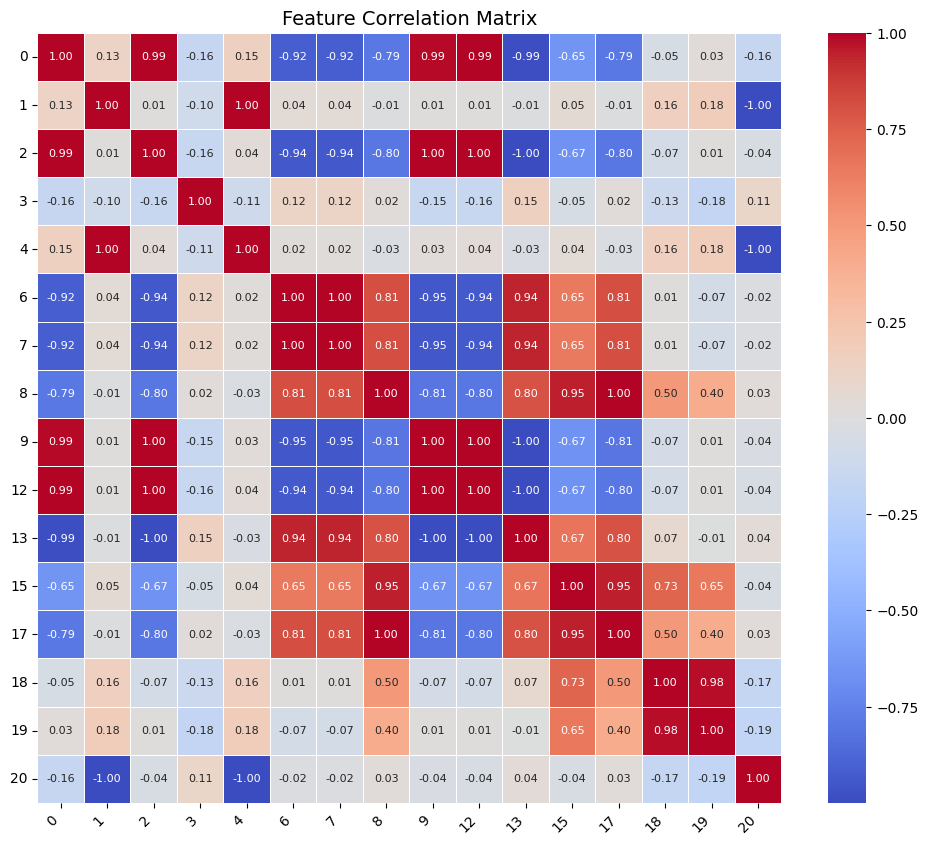

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df_train_features.corr().fillna(0)

plt.figure(figsize=(12, 10)) 

sns.heatmap(
    correlation_matrix, 
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm", 
    linewidths=0.5,
    annot_kws={"size": 8}  
)

plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0) 

plt.title("Feature Correlation Matrix", fontsize=14)

plt.show()

In [20]:
# import numpy as np

# corr_matrix = df_train_features.corr().abs()  # Get absolute correlation values

# upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

# df_train_features = df_train_features.drop(columns=to_drop)
# df_test_features = df_test_features.drop(columns=to_drop)
# df_val_features = df_val_features.drop(columns=to_drop)

# print(f"Dropped highly correlated columns: {to_drop}")

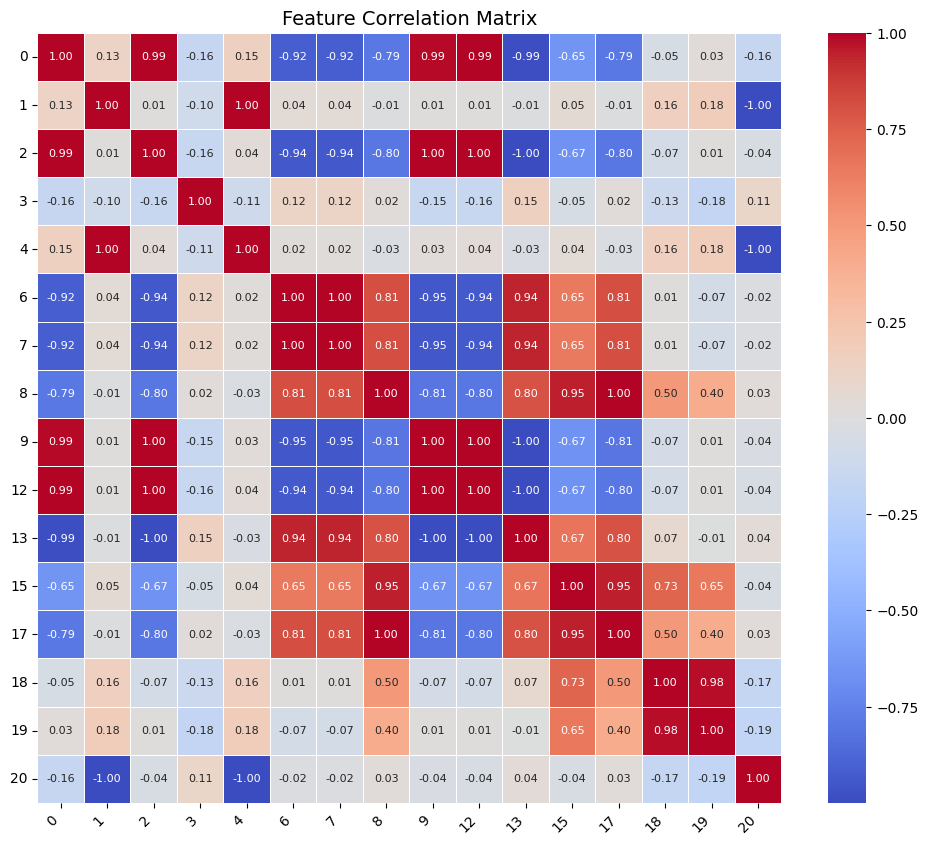

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df_train_features.corr().fillna(0)

plt.figure(figsize=(12, 10)) 

sns.heatmap(
    correlation_matrix, 
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm", 
    linewidths=0.5,
    annot_kws={"size": 8}  
)

plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0) 

plt.title("Feature Correlation Matrix", fontsize=14)

plt.show()

## features extraction

In [22]:
df_train_features = df_train_features.fillna(0)
df_test_features = df_test_features.fillna(0)
df_val_features = df_val_features.fillna(0)

In [23]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=0.95)
# df_train_features = pca.fit_transform(df_train_features)
# df_val_features = pca.transform(df_val_features)
# df_test_features = pca.transform(df_test_features)

# num_components = pca.n_components_
# input_size = num_components
# print(f"Number of components selected to retain 95% variance: {num_components}")

In [24]:
df_train_features = pd.DataFrame(df_train_features)
df_val_features = pd.DataFrame(df_val_features)
df_test_features = pd.DataFrame(df_test_features)

# Deep Learning

In [25]:
import torch
import numpy as np
import random

def set_seed(seed=0):
    torch.manual_seed(seed)  # Sets PyTorch seed (CPU)
    torch.cuda.manual_seed(seed)  # Sets PyTorch seed (GPU)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    np.random.seed(seed)  # Sets NumPy seed
    random.seed(seed)  # Sets Python random seed

    torch.backends.cudnn.deterministic = True  # Ensures deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disables cuDNN optimization for reproducibility

set_seed(0)  # Set seed to 0

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
# Define constants
NUM_SIGNALS = num_signals  # Number of signals per segment (e.g., t, x, y, x_left, y_left)
NUM_FEATURES = num_features  # Number of features per signal (e.g., raw, velocity, acceleration)
SEQUENCE_LENGTH = 2 * CONTEXT + 1  # Assuming this is 201

def reshape_data(df_signals, df_labels, df_features, df_subsequences):
    """
    Transforms data into shape (num_samples, num_features, num_signals, sequence_length)
    by grouping signals that originated from the same segment.
    """
    # Convert DataFrame to numpy
    X = df_signals.values  # Shape: (total_samples, sequence_length)
    y = df_labels.values.flatten()  # Shape: (total_samples,)
    X_features = df_features.values
    subseq = df_subsequences.values.flatten()  # Shape: (total_samples,)

    # Store results
    X_train_list, y_train_list, X_train_features_list = [], [], []

    # Group by unique segments
    unique_segments = np.unique(subseq)

    for segment in unique_segments:
        # Get indices for the current segment
        segment_indices = np.where(subseq == segment)[0]

        # Extract data for the segment
        X_segment = X[segment_indices]  # Shape: (num_samples_in_segment, sequence_length)
        y_segment = y[segment_indices]  # Shape: (num_samples_in_segment,)
        X_features_segment = X_features[segment_indices]
        
        # Ensure we have at least NUM_SIGNALS samples
        if len(segment_indices) < NUM_SIGNALS:
            continue  # Skip segments with too few samples

        num_samples_in_segment = X_segment.shape[0]

        # Trim `X_segment` to be divisible by `NUM_SIGNALS`
        num_samples_trimmed = (num_samples_in_segment // NUM_SIGNALS) * NUM_SIGNALS
        if num_samples_trimmed == 0:
            continue  # Skip if not enough samples after trimming

        X_segment = X_segment[:num_samples_trimmed]  # Trim to the nearest multiple of NUM_SIGNALS
        y_segment = y_segment[:num_samples_trimmed]  # Trim labels accordingly
        X_features_segment = X_features_segment[:num_samples_trimmed]
        
        # Compute the number of groups
        num_groups = num_samples_trimmed // NUM_SIGNALS

        # **Fix: Verify actual and expected size before reshaping**
        actual_elements = X_segment.size
        expected_elements = num_groups * NUM_SIGNALS * SEQUENCE_LENGTH
        if actual_elements != expected_elements:
            print(f"Skipping segment {segment} due to size mismatch: expected {expected_elements}, got {actual_elements}")
            continue

        # Reshape into (num_groups, num_signals, sequence_length)
        X_segment = X_segment.reshape(num_groups, NUM_SIGNALS, SEQUENCE_LENGTH)

        # **Fix: Add features as a new dimension**
        X_segment = np.expand_dims(X_segment, axis=2)  # Shape: (num_groups, num_signals, 1, sequence_length)
        X_segment = np.repeat(X_segment, NUM_FEATURES, axis=2)  # Expand to (num_groups, num_signals, num_features, sequence_length)

        # Transpose to match CNN input format: (num_samples, num_features, num_signals, sequence_length)
        X_segment = np.transpose(X_segment, (0, 2, 1, 3))  # (num_samples, num_features, num_signals, sequence_length)

        # Append to dataset
        X_train_list.append(X_segment)
        y_train_list.append(y_segment[::NUM_SIGNALS])  # Take one label per group
        X_train_features_list.append(X_features_segment[::NUM_SIGNALS])

    # Convert to numpy arrays
    if len(X_train_list) == 0:
        print("⚠ Warning: No valid segments found! Returning empty arrays.")
        return np.array([]), np.array([])  # Return empty arrays if no valid segments were found

    X_train = np.concatenate(X_train_list, axis=0)  # Shape: (num_samples, num_features, num_signals, sequence_length)
    y_train = np.concatenate(y_train_list, axis=0)  # Shape: (num_samples,)
    X_train_features = np.concatenate(X_train_features_list, axis=0)

    return X_train, X_train_features, y_train

X_train, X_train_features, y_train = reshape_data(df_train_signals, df_train_labels, df_train_features, df_train_subsequnces)
X_test, X_test_features, y_test = reshape_data(df_test_signals, df_test_labels, df_test_features, df_test_subsequnces)
X_val, X_val_features, y_val = reshape_data(df_val_signals, df_val_labels, df_val_features, df_val_subsequnces)

In [28]:
X_train.shape

(214, 6, 10, 201)

In [29]:
y_train.shape

(214,)

In [30]:
X_train_features.shape

(214, 16)

In [31]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# # Convert DataFrames to numpy arrays
# X_train = df_train_signals.values.astype(np.float32)
# y_train = df_train_labels["label"].values[::num_features].astype(np.int64)
# X_train_features = df_train_features.values[::num_features].astype(np.float32)

# X_val = df_val_signals.values.astype(np.float32)
# y_val = df_val_labels["label"].values[::num_features].astype(np.int64)
# X_val_features = df_val_features.values[::num_features].astype(np.float32)

# X_test = df_test_signals.values.astype(np.float32)
# y_test = df_test_labels["label"].values[::num_features].astype(np.int64)
# X_test_features = df_test_features.values[::num_features].astype(np.float32)

# # Define sequence length and number of features
# sequence_length = 2 * CONTEXT + 1  # Each sample consists of `sequence_length` timestamps

# # Reshape CNN inputs to match the expected input format (batch, channels, sequence_length)
# X_train = X_train.reshape(-1, num_features, sequence_length)  # Shape: (num_samples, num_features, sequence_length)
# X_val = X_val.reshape(-1, num_features, sequence_length)
# X_test = X_test.reshape(-1, num_features, sequence_length)

# Print dataset shapes for verification
print("Shapes of datasets:")
print(f"X_train (CNN input): {X_train.shape}")
print(f"y_train (Labels): {y_train.shape}")
print(f"Unique labels in y_train: {np.unique(y_train)}")
print(f"X_train_features (FC input): {X_train_features.shape}")

# Define PyTorch Dataset for CNN and FC input
class MergedDataset(Dataset):
    def __init__(self, X_cnn, X_fc, y):
        self.X_cnn = torch.tensor(X_cnn, dtype=torch.float32)  # CNN input
        self.X_fc = torch.tensor(X_fc, dtype=torch.float32)  # FC input
        self.y = torch.tensor(y, dtype=torch.int64)  # Labels

    def __len__(self):
        return len(self.X_cnn)

    def __getitem__(self, idx):
        return self.X_cnn[idx], self.X_fc[idx], self.y[idx]

# Create Dataloaders
train_dataset = MergedDataset(X_train, X_train_features, y_train)
val_dataset = MergedDataset(X_val, X_val_features, y_val)
test_dataset = MergedDataset(X_test, X_test_features, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check for NaNs and Infs
print("Checking for NaNs and Infs in dataset...")
print(f"NaNs in X_train: {np.isnan(X_train).sum()}, NaNs in y_train: {np.isnan(y_train).sum()}")
print(f"Infs in X_train: {np.isinf(X_train).sum()}, Infs in y_train: {np.isinf(y_train).sum()}")
print(f"NaNs in X_train_features: {np.isnan(X_train_features).sum()}")
print(f"Infs in X_train_features: {np.isinf(X_train_features).sum()}")


Shapes of datasets:
X_train (CNN input): (214, 6, 10, 201)
y_train (Labels): (214,)
Unique labels in y_train: [0 1 2]
X_train_features (FC input): (214, 16)
Checking for NaNs and Infs in dataset...
NaNs in X_train: 0, NaNs in y_train: 0
Infs in X_train: 0, Infs in y_train: 0
NaNs in X_train_features: 0
Infs in X_train_features: 0


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNBranch(nn.Module):
    def __init__(self, cnn_out_features):
        super(CNNBranch, self).__init__()

        neurons = np.array([4, 8, 16, 32]) * 64
        
        # First Conv2D Layer: Input (num_features, num_signals, sequence_length)
        self.conv1 = nn.Conv2d(in_channels=num_signals, out_channels=neurons[0], kernel_size=(4, 32), stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(neurons[0])

        # Second Conv2D Layer
        self.conv2 = nn.Conv2d(neurons[0], neurons[1], kernel_size=(2, 16), stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(neurons[1])

        # Third Conv2D Layer
        self.conv3 = nn.Conv2d(neurons[1], neurons[2], kernel_size=(1, 8), stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(neurons[2])

        # Pooling and Dropout Layers1
        self.pool = nn.MaxPool2d(kernel_size=(2, 4), stride=2)
        self.dropout1 = nn.Dropout(0.1)

        # Adaptive Pooling to flatten spatial dimensions
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully Connected Layers
        self.fc1 = nn.Linear(neurons[2], neurons[3])
        self.fc2 = nn.Linear(neurons[3], cnn_out_features)

    def forward(self, x):
        """
        Forward pass through the 2D CNN.
        Input shape: (batch_size, num_features, num_signals, sequence_length)
        """
        x = x.permute(0,2,1,3)
        x = nn.ReLU()(self.bn1(self.conv1(x)))  # Convolution + BatchNorm + ReLU
        x = self.pool(x)  # Downsample
        
        x = nn.ReLU()(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = nn.ReLU()(self.bn3(self.conv3(x)))
        x = self.pool(x)

        x = self.global_pool(x)  # Adaptive Pooling to (batch_size, neurons[2], 1, 1)
        x = x.view(x.size(0), -1)  # Flatten to (batch_size, neurons[2])

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)

        return x

class FCBranch(nn.Module):
    def __init__(self, fc_out_features):
        super(FCBranch, self).__init__()
        
        # Best hyperparameters from Optuna
        neurons = np.array([512, 512, 256, 512])
        dropout_rate = 0.22830940644606096

        # Layers
        self.fc1 = nn.Linear(input_size, neurons[0])
        self.fc2 = nn.Linear(neurons[0], neurons[1])
        self.fc3 = nn.Linear(neurons[1], neurons[2])
        self.fc4 = nn.Linear(neurons[2], neurons[3])
        self.fc5 = nn.Linear(neurons[3], fc_out_features)

        # Activation and dropout
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc4(x)
        x = self.relu(x)

        x = self.fc5(x)

        return x

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model with tunable hyperparameters
class NN(nn.Module):
    def __init__(self, num_features, sequence_length, input_size, num_classes, 
                 cnn_out_features, fc_out_features, neurons_per_layer, dropout, dropout_layers):
        super(NN, self).__init__()

        # CNN & FC Branches
        self.cnn_branch = CNNBranch(cnn_out_features)
        self.fc_branch = FCBranch(fc_out_features)

        # Merge both branches
        merged_features = cnn_out_features + fc_out_features

        # Dense layers
        self.layers = nn.ModuleList()
        prev_neurons = merged_features

        for i, neurons in enumerate(neurons_per_layer):
            self.layers.append(nn.Linear(prev_neurons, neurons))
            self.layers.append(nn.ReLU())

            if i in dropout_layers:  # Apply dropout only at selected layers
                self.layers.append(nn.Dropout(dropout))

            prev_neurons = neurons

        self.fc_out = nn.Linear(prev_neurons, num_classes)  # Final layer

    def forward(self, x_cnn, x_fc):
        cnn_out = self.cnn_branch(x_cnn)
        fc_out = self.fc_branch(x_fc)

        # Concatenate both feature vectors
        x = torch.cat((cnn_out, fc_out), dim=1)

        # Pass through additional dense layers
        for layer in self.layers:
            x = layer(x)

        return self.fc_out(x)  # No activation here, softmax/sigmoid handled by loss function

# Function to train and evaluate model
def train_model(model, train_loader, optimizer, criterion, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_cnn, X_fc, y_batch in train_loader:  
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_cnn, X_fc)  
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
    
    return accuracy

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X_cnn, X_fc, y_batch in test_loader:  
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            outputs = model(X_cnn, X_fc)  
            
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy

# Objective function for Optuna (Runs 5 times and averages accuracy)
def objective(trial):
    # Hyperparameter search space
    cnn_out_features = trial.suggest_categorical("cnn_out_features", [32, 64, 128, 256])
    fc_out_features = trial.suggest_categorical("fc_out_features", [32, 64, 128, 256])
    
    num_layers = trial.suggest_int("num_layers", 1, 4)
    neurons_per_layer = [trial.suggest_categorical(f"neurons_l{i}", [64, 128, 256, 512]) for i in range(num_layers)]
    
    dropout = trial.suggest_float("dropout", 0.05, 0.5)
    dropout_layers = trial.suggest_categorical("dropout_layers", [[], [0], [1], [0, 2], [1, 3]])

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)

    accuracies = []  # Store accuracies for 5 runs

    for _ in range(5):  # Run the same setup 5 times
        # Initialize model
        model = NN(num_features=num_features, sequence_length=sequence_length, 
                   input_size=input_size, num_classes=len(np.unique(y_train)),
                   cnn_out_features=cnn_out_features, fc_out_features=fc_out_features, 
                   neurons_per_layer=neurons_per_layer, dropout=dropout, dropout_layers=dropout_layers).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

        # Train the model
        train_model(model, train_loader, optimizer, criterion, num_epochs=10)

        # Evaluate model on test set
        test_accuracy = evaluate_model(model, test_loader)

        accuracies.append(test_accuracy)  # Store result

    avg_accuracy = np.mean(accuracies)  # Compute average accuracy
    print(f"Trial {trial.number}: Avg Accuracy = {avg_accuracy:.2f}%")
    
    return avg_accuracy  # Optuna will try to maximize this

# Run Optuna optimization
study = optuna.create_study(direction="maximize")  # We want to maximize accuracy
study.optimize(objective, n_trials=20)  # Perform 20 trials

# Best hyperparameters
print("Best Hyperparameters:", study.best_params)

# Visualization of results
fig, ax = plt.subplots(figsize=(8, 5))

# Plot accuracy over trials
ax.plot(study.trials_dataframe()["value"], marker="o", linestyle="-", color="b")
ax.set_title("Optimization Progress")
ax.set_xlabel("Trial")
ax.set_ylabel("Accuracy")

plt.show()

# Optuna built-in visualizations
optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_optimization_history(study).show()


[I 2025-03-09 15:41:07,043] A new study created in memory with name: no-name-69e40167-53cc-4a86-95c8-c0118f095bd1
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [] which is of type list.
  warnings.warn(message)
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [0] which is of type list.
  warnings.warn(message)
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float an

KeyboardInterrupt: 

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# CNN Branch
class CNNBranch(nn.Module):
    def __init__(self, cnn_out_features):
        super(CNNBranch, self).__init__()

        neurons = np.array([4, 8, 16, 32]) * 64
        
        # First Conv2D Layer: Input (num_features, num_signals, sequence_length)
        self.conv1 = nn.Conv2d(in_channels=num_signals, out_channels=neurons[0], kernel_size=(4, 32), stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(neurons[0])

        # Second Conv2D Layer
        self.conv2 = nn.Conv2d(neurons[0], neurons[1], kernel_size=(2, 16), stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(neurons[1])

        # Third Conv2D Layer
        self.conv3 = nn.Conv2d(neurons[1], neurons[2], kernel_size=(1, 8), stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(neurons[2])

        # Pooling and Dropout Layers1
        self.pool = nn.MaxPool2d(kernel_size=(2, 4), stride=2)
        self.dropout1 = nn.Dropout(0.1)

        # Adaptive Pooling to flatten spatial dimensions
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully Connected Layers
        self.fc1 = nn.Linear(neurons[2], neurons[3])
        self.fc2 = nn.Linear(neurons[3], cnn_out_features)

    def forward(self, x):
        """
        Forward pass through the 2D CNN.
        Input shape: (batch_size, num_features, num_signals, sequence_length)
        """
        x = x.permute(0,2,1,3)
        x = nn.ReLU()(self.bn1(self.conv1(x)))  # Convolution + BatchNorm + ReLU
        x = self.pool(x)  # Downsample
        
        x = nn.ReLU()(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = nn.ReLU()(self.bn3(self.conv3(x)))
        x = self.pool(x)

        x = self.global_pool(x)  # Adaptive Pooling to (batch_size, neurons[2], 1, 1)
        x = x.view(x.size(0), -1)  # Flatten to (batch_size, neurons[2])

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)

        return x


class FCBranch(nn.Module):
    def __init__(self, fc_out_features):
        super(FCBranch, self).__init__()
        
        # Best hyperparameters from Optuna
        neurons = np.array([512, 512, 256, 512])
        dropout_rate = 0.22830940644606096

        # Layers
        self.fc1 = nn.Linear(input_size, neurons[0])
        self.fc2 = nn.Linear(neurons[0], neurons[1])
        self.fc3 = nn.Linear(neurons[1], neurons[2])
        self.fc4 = nn.Linear(neurons[2], neurons[3])
        self.fc5 = nn.Linear(neurons[3], fc_out_features)

        # Activation and dropout
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc4(x)
        x = self.relu(x)

        x = self.fc5(x)

        return x

# **Merged Model**
class NN(nn.Module):
    def __init__(self, num_features, sequence_length, input_size, num_classes):
        super(NN, self).__init__()

        # Best hyperparameters
        cnn_out_features = 64
        fc_out_features = 32
        num_layers = 4
        neurons = [64, 512, 512, 64]  # As per best hyperparameters
        dropout_rate = 0.38101372981359927
        dropout_layers = []  # No specific dropout layers specified

        # CNN & FC Branches
        self.cnn_branch = CNNBranch(cnn_out_features)
        self.fc_branch = FCBranch(fc_out_features)

        # Merge both branches
        merged_features = cnn_out_features + fc_out_features

        # Fully Connected Layers
        self.layers = nn.ModuleList()
        prev_neurons = merged_features

        for i, neurons_count in enumerate(neurons):
            self.layers.append(nn.Linear(prev_neurons, neurons_count))
            self.layers.append(nn.ReLU())

            if i in dropout_layers:  # Apply dropout only at selected layers
                self.layers.append(nn.Dropout(dropout_rate))

            prev_neurons = neurons_count

        # Output layer (No activation, handled by loss function)
        self.fc_out = nn.Linear(prev_neurons, num_classes)

    def forward(self, x_cnn, x_fc):
        cnn_out = self.cnn_branch(x_cnn)
        fc_out = self.fc_branch(x_fc)

        # Concatenate CNN and FC branch outputs
        x = torch.cat((cnn_out, fc_out), dim=1)

        # Pass through dense layers
        for layer in self.layers:
            x = layer(x)

        return self.fc_out(x)  # Logits output








Epoch 1/10, Loss: 7.4754, Accuracy: 51.87%
Epoch 2/10, Loss: 6.5688, Accuracy: 65.89%
Epoch 3/10, Loss: 5.1981, Accuracy: 66.36%
Epoch 4/10, Loss: 4.7208, Accuracy: 69.16%
Epoch 5/10, Loss: 4.5750, Accuracy: 68.22%
Epoch 6/10, Loss: 4.4357, Accuracy: 70.56%
Epoch 7/10, Loss: 4.4965, Accuracy: 69.63%
Epoch 8/10, Loss: 4.9244, Accuracy: 68.69%
Epoch 9/10, Loss: 3.9851, Accuracy: 72.90%
Epoch 10/10, Loss: 4.3571, Accuracy: 67.76%
Test Accuracy: 53.12%

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       1.00      0.27      0.43        22
           2       0.52      1.00      0.68        28

    accuracy                           0.53        64
   macro avg       0.51      0.42      0.37        64
weighted avg       0.57      0.53      0.45        64



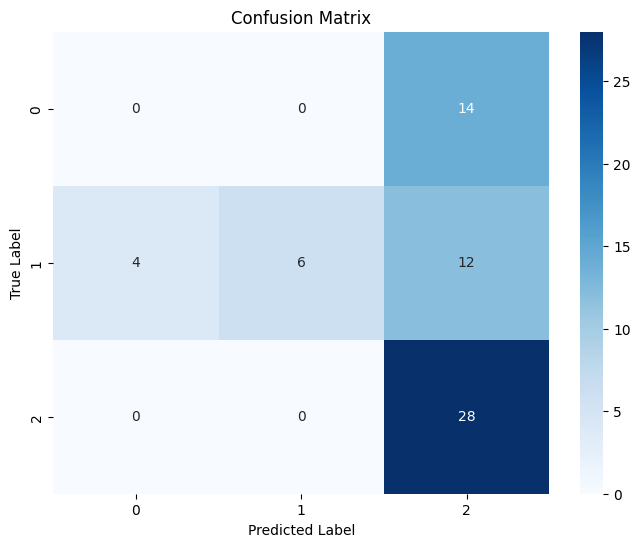

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
num_features, sequence_length, input_size, num_classes
model = NN(
    num_features=num_features,
    sequence_length=sequence_length,
    input_size=input_size, 
    num_classes=num_classes
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00011850377266214412, weight_decay=1e-5)

# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_cnn, X_fc, y_batch in train_loader:  # Unpack all three inputs
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_cnn, X_fc)  # Pass both inputs to the model
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")


# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_cnn, X_fc, y_batch in test_loader:  # Unpack all three inputs
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            outputs = model(X_cnn, X_fc)  # Pass both inputs
            
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Test the model and show confusion matrix
evaluate_model(model, test_loader)


Epoch 1/10, Loss: 6.9689, Accuracy: 44.86%
Epoch 2/10, Loss: 5.5631, Accuracy: 62.62%
Epoch 3/10, Loss: 5.5300, Accuracy: 61.68%
Epoch 4/10, Loss: 4.8581, Accuracy: 67.29%
Epoch 5/10, Loss: 4.8347, Accuracy: 66.36%
Epoch 6/10, Loss: 5.1968, Accuracy: 65.42%
Epoch 7/10, Loss: 4.3080, Accuracy: 68.22%
Epoch 8/10, Loss: 3.3470, Accuracy: 72.90%
Epoch 9/10, Loss: 3.4612, Accuracy: 78.50%
Epoch 10/10, Loss: 2.1896, Accuracy: 83.64%
Test Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        22
           2       1.00      1.00      1.00        28

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



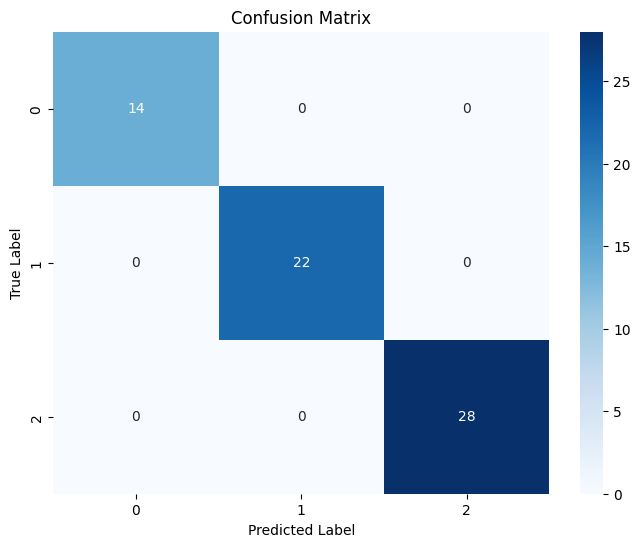

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model Initialization
num_classes = len(np.unique(y_train))
model = NN(
    num_features=num_features,
    sequence_length=sequence_length,
    input_size=input_size, 
    num_classes=num_classes
).to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer & Learning Rate Scheduler
optimizer = optim.AdamW(model.parameters(), lr=0.0006287438644196367, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Training Function
def train_model(model, train_loader, num_epochs=10):
    model.train()
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0

        for X_cnn, X_fc, y_batch in train_loader:
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_cnn, X_fc)
            loss = criterion(outputs, y_batch)
            loss.backward()

            # Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        # Learning Rate Scheduler Step
        scheduler.step()

        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Evaluation Function
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_cnn, X_fc, y_batch in test_loader:
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            outputs = model(X_cnn, X_fc)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Training & Evaluation
train_model(model, train_loader, num_epochs=10)
evaluate_model(model, test_loader)


Epoch 1/50 - Loss: 6.8877 - Train Acc: 55.14% - Val AUC-ROC: 0.7866
✅ New Best Model Saved! AUC-ROC: 0.7866
Epoch 2/50 - Loss: 6.5227 - Train Acc: 66.36% - Val AUC-ROC: 0.8272
✅ New Best Model Saved! AUC-ROC: 0.8272
Epoch 3/50 - Loss: 5.3747 - Train Acc: 61.68% - Val AUC-ROC: 0.8290
✅ New Best Model Saved! AUC-ROC: 0.8290
Epoch 4/50 - Loss: 4.7900 - Train Acc: 68.69% - Val AUC-ROC: 0.7866
⏳ Early Stopping Counter: 1/5
Epoch 5/50 - Loss: 5.2175 - Train Acc: 66.82% - Val AUC-ROC: 0.7866
⏳ Early Stopping Counter: 2/5
Epoch 6/50 - Loss: 4.5783 - Train Acc: 67.76% - Val AUC-ROC: 0.8298
✅ New Best Model Saved! AUC-ROC: 0.8298
Epoch 7/50 - Loss: 4.4145 - Train Acc: 67.76% - Val AUC-ROC: 0.8704
✅ New Best Model Saved! AUC-ROC: 0.8704
Epoch 8/50 - Loss: 3.8037 - Train Acc: 71.96% - Val AUC-ROC: 0.9398
✅ New Best Model Saved! AUC-ROC: 0.9398
Epoch 9/50 - Loss: 3.2222 - Train Acc: 78.50% - Val AUC-ROC: 0.8833
⏳ Early Stopping Counter: 1/5
Epoch 10/50 - Loss: 2.3624 - Train Acc: 82.71% - Val AUC-R

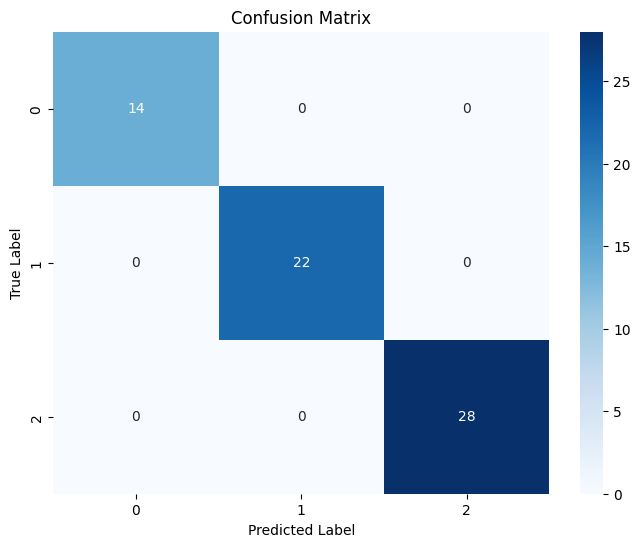

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from torch.utils.data import Dataset, DataLoader

# Model Setup
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(
    num_features=num_features,
    sequence_length=sequence_length,
    input_size=input_size, 
    num_classes=num_classes
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0006287438644196367, weight_decay=1e-5)

# Training with Early Stopping & AUC-ROC Monitoring
def train_model(model, train_loader, val_loader, num_epochs=50, patience=5):
    best_auc_roc = 0.0
    patience_counter = 0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X_cnn, X_fc, y_batch in train_loader:  # Correct unpacking
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_cnn, X_fc)

            # ✅ Check for NaNs in outputs
            if torch.isnan(outputs).sum() > 0 or torch.isinf(outputs).sum() > 0:
                print("⚠️ NaN/Inf detected in model output! Skipping batch.")
                continue  # Skip this batch

            loss = criterion(outputs, y_batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ✅ Gradient Clipping
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_accuracy = 100 * correct / total
        val_auc_roc = evaluate_auc_roc(model, val_loader, num_classes)  # Compute AUC-ROC

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f} - Train Acc: {train_accuracy:.2f}% - Val AUC-ROC: {val_auc_roc:.4f}")

        # ✅ Early Stopping
        if val_auc_roc > best_auc_roc:
            best_auc_roc = val_auc_roc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)  # Save Best Model
            print(f"✅ New Best Model Saved! AUC-ROC: {best_auc_roc:.4f}")
        else:
            patience_counter += 1
            print(f"⏳ Early Stopping Counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"⏹️ Early Stopping Triggered! Best AUC-ROC: {best_auc_roc:.4f}")
            break

    print("🎉 Training Complete!")

from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

from sklearn.preprocessing import label_binarize

def evaluate_auc_roc(model, val_loader, num_classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_cnn, X_fc, y_batch in val_loader:  # Correct unpacking
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            outputs = model(X_cnn, X_fc)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Convert to probabilities
            all_preds.extend(probabilities)
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # ✅ Handle NaNs
    if np.isnan(all_preds).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ NaN values detected in predictions or labels.")
        all_preds = np.nan_to_num(all_preds)
        all_labels = np.nan_to_num(all_labels)

    # ✅ Ensure multiple classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Only one class present in all_labels. AUC-ROC cannot be computed.")
        return 0.0

    all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))

    try:
        if num_classes > 2:
            return roc_auc_score(all_labels_bin, all_preds, multi_class='ovo')
        else:
            return roc_auc_score(all_labels, all_preds[:, 1])  # Binary AUC-ROC
    except ValueError as e:
        print(f"❌ Error in AUC-ROC computation: {e}")
        return 0.0  # Return default if error occurs



# Train Model
train_model(model, train_loader, val_loader, num_epochs=50, patience=5)

# Load Best Model and Evaluate on Test Set
best_model = NN(
    num_features=num_features,
    sequence_length=sequence_length,
    input_size=input_size, 
    num_classes=num_classes
).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()

from sklearn.metrics import precision_recall_fscore_support

from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def evaluate_model(model, test_loader, num_classes):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_cnn, X_fc, y_batch in test_loader:  # Correct unpacking
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            outputs = model(X_cnn, X_fc)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_probs.extend(probabilities)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # ✅ Handle NaNs
    if np.isnan(all_probs).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ NaN values detected. Replacing with zeros.")
        all_probs = np.nan_to_num(all_probs)
        all_labels = np.nan_to_num(all_labels)

    # ✅ Compute Metrics
    auc_roc = evaluate_auc_roc(model, test_loader, num_classes)
    accuracy = 100 * correct / total if total > 0 else 0.0

    print(f"\n✅ Test Accuracy: {accuracy:.2f}%")
    print(f"✅ Test AUC-ROC: {auc_roc:.4f}\n")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("\n📌 Classification Report:\n", classification_report(all_labels, all_preds, digits=4))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()



# Evaluate Best Model
evaluate_model(best_model, test_loader, num_classes)


/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 - Loss: 6.9256 - Train Acc: 50.47% - Val AUC-ROC: 0.7756
✅ New Best Model Saved! AUC-ROC: 0.7756
Epoch 2/50 - Loss: 5.6262 - Train Acc: 63.55% - Val AUC-ROC: 0.7756
⏳ Early Stopping Counter: 1/5
Epoch 3/50 - Loss: 5.1757 - Train Acc: 67.29% - Val AUC-ROC: 0.8333
✅ New Best Model Saved! AUC-ROC: 0.8333
Epoch 4/50 - Loss: 4.6547 - Train Acc: 66.36% - Val AUC-ROC: 0.7965
⏳ Early Stopping Counter: 1/5
Epoch 5/50 - Loss: 5.2938 - Train Acc: 67.76% - Val AUC-ROC: 0.7965
⏳ Early Stopping Counter: 2/5
Epoch 6/50 - Loss: 5.0623 - Train Acc: 65.42% - Val AUC-ROC: 0.8173
⏳ Early Stopping Counter: 3/5
Epoch 7/50 - Loss: 4.3713 - Train Acc: 70.09% - Val AUC-ROC: 0.8173
⏳ Early Stopping Counter: 4/5
Epoch 8/50 - Loss: 4.7867 - Train Acc: 68.69% - Val AUC-ROC: 0.8173
⏳ Early Stopping Counter: 5/5
⏹️ Early Stopping Triggered! Best AUC-ROC: 0.8333
🎉 Training Complete!

✅ Test Accuracy: 78.12%
✅ Test AUC-ROC: 0.7373


📌 Classification Report:
               precision    recall  f1-score   sup

/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/arturstef/.cache/pypoetry/virtualenvs/saccade-analysis-v68S8k7S-py3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

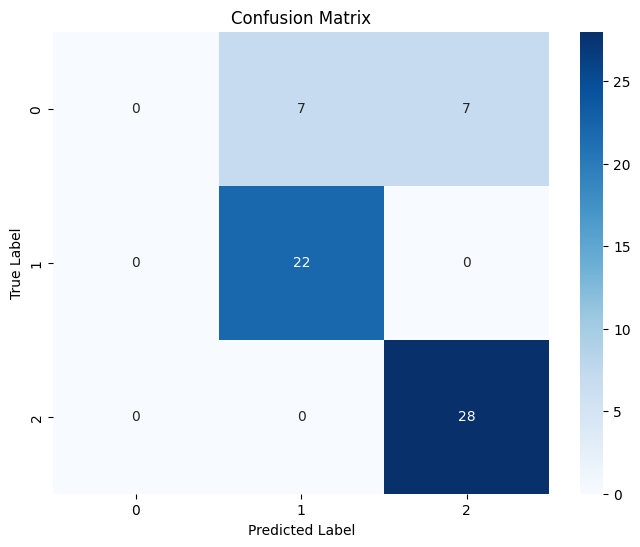

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from torch.utils.data import Dataset, DataLoader

# Model Setup
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(
    num_features=num_features,
    sequence_length=sequence_length,
    input_size=input_size, 
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

# ✅ Optimizer: AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=0.0006287438644196367, weight_decay=1e-5)

# ✅ Learning Rate Scheduler: Reduce LR if validation AUC-ROC doesn't improve
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

# 🔹 Training with Early Stopping & AUC-ROC Monitoring
def train_model(model, train_loader, val_loader, num_epochs=50, patience=5):
    best_auc_roc = 0.0
    patience_counter = 0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X_cnn, X_fc, y_batch in train_loader:
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_cnn, X_fc)

            # ✅ Check for NaNs in outputs
            if torch.isnan(outputs).sum() > 0 or torch.isinf(outputs).sum() > 0:
                print("⚠️ NaN/Inf detected in model output! Skipping batch.")
                continue

            loss = criterion(outputs, y_batch)
            loss.backward()

            # ✅ Gradient Clipping to avoid exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_accuracy = 100 * correct / total
        val_auc_roc = evaluate_auc_roc(model, val_loader, num_classes)  # Compute AUC-ROC

        # 🔹 Adjust Learning Rate based on Validation AUC-ROC
        scheduler.step(val_auc_roc)

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f} - Train Acc: {train_accuracy:.2f}% - Val AUC-ROC: {val_auc_roc:.4f}")

        # ✅ Early Stopping
        if val_auc_roc > best_auc_roc:
            best_auc_roc = val_auc_roc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)  # Save Best Model
            print(f"✅ New Best Model Saved! AUC-ROC: {best_auc_roc:.4f}")
        else:
            patience_counter += 1
            print(f"⏳ Early Stopping Counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"⏹️ Early Stopping Triggered! Best AUC-ROC: {best_auc_roc:.4f}")
            break

    print("🎉 Training Complete!")

# 🔹 AUC-ROC Evaluation Function
def evaluate_auc_roc(model, val_loader, num_classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_cnn, X_fc, y_batch in val_loader:
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            outputs = model(X_cnn, X_fc)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Convert to probabilities
            all_preds.extend(probabilities)
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # ✅ Handle NaNs
    if np.isnan(all_preds).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ NaN values detected in predictions or labels. Replacing with zeros.")
        all_preds = np.nan_to_num(all_preds)
        all_labels = np.nan_to_num(all_labels)

    # ✅ Ensure multiple classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Only one class present in all_labels. AUC-ROC cannot be computed.")
        return 0.0

    try:
        if num_classes > 2:
            return roc_auc_score(all_labels, all_preds, multi_class='ovo')
        else:
            return roc_auc_score(all_labels, all_preds[:, 1])  # Binary AUC-ROC
    except ValueError as e:
        print(f"❌ Error in AUC-ROC computation: {e}")
        return 0.0  # Return default if error occurs


# ✅ Train Model
train_model(model, train_loader, val_loader, num_epochs=50, patience=5)

# ✅ Load Best Model for Testing
best_model = NN(
    num_features=num_features,
    sequence_length=sequence_length,
    input_size=input_size, 
    num_classes=num_classes
).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()

# 🔹 Evaluation Function
def evaluate_model(model, test_loader, num_classes):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_cnn, X_fc, y_batch in test_loader:
            X_cnn, X_fc, y_batch = X_cnn.to(device), X_fc.to(device), y_batch.to(device)
            outputs = model(X_cnn, X_fc)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_probs.extend(probabilities)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    accuracy = 100 * correct / total if total > 0 else 0.0
    auc_roc = evaluate_auc_roc(model, test_loader, num_classes)

    print(f"\n✅ Test Accuracy: {accuracy:.2f}%")
    print(f"✅ Test AUC-ROC: {auc_roc:.4f}\n")

    # ✅ Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\n📌 Classification Report:\n", classification_report(all_labels, all_preds, digits=4))

    # 🔹 Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# ✅ Evaluate Best Model
evaluate_model(best_model, test_loader, num_classes)
